# Portfolio Optimization — Interactive Exploration

This notebook walks you through the entire data and MVO pipeline step by step.
Run each cell and read the comments — they explain what's happening and why.

**Learning path:**
1. Load and inspect the raw price data
2. Compute and visualize returns
3. Understand the covariance matrix and correlations
4. Run Markowitz optimization (min-variance and max-Sharpe)
5. Visualize the efficient frontier
6. Run a backtest and analyze performance by volatility regime

**Prerequisite:** Make sure you selected the **"Portfolio Optimization"** kernel (top right).

In [5]:
# --- Setup: import everything we need ---
import sys
sys.path.insert(0, "..")  # so we can import from src/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Our project modules
from src.config import TICKERS, START_DATE, END_DATE, RAW_DATA_DIR
from src.data import load_dataset
from src.data.preprocessing import compute_log_returns, compute_simple_returns
from src.models.mvo import (
    estimate_parameters, portfolio_performance,
    minimum_variance_weights, max_sharpe_weights,
    efficient_frontier, rolling_backtest,
)
from src.risk_metrics import compute_all_metrics, sharpe_ratio
from src.visualization import (
    plot_efficient_frontier, plot_cumulative_returns,
    plot_weight_allocation, plot_regime_returns,
    plot_drawdown, plot_rolling_sharpe,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
print("All imports successful!")

All imports successful!


## Step 1: Load the Dataset

`load_dataset()` does everything in one call:
1. Downloads adjusted close prices from Yahoo Finance (or reads from cache)
2. Downloads VIX data (the "fear gauge")
3. Computes log returns and simple returns
4. Labels each day as low/medium/high volatility regime
5. Splits into train (70%) / validation (15%) / test (15%) — **temporally**, not randomly

In [8]:
# Load the full dataset (uses cache after first run)
data = load_dataset(tickers=TICKERS, start=START_DATE, end=END_DATE, cache_dir=RAW_DATA_DIR)

print(f"Tickers: {TICKERS}")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"\nPrices shape: {data['prices'].shape}  (rows=trading days, cols=ETFs)")
print(f"Log returns shape: {data['log_returns'].shape}")
print(f"\nTrain: {len(data['train'])} days | Val: {len(data['val'])} days | Test: {len(data['test'])} days")
print(f"\nVolatility regime distribution:")
print(data["regime_vix"].value_counts())


Tickers: ['XLK', 'XLF', 'XLE', 'XLY', 'XLV', 'XLP', 'XLI', 'XLB', 'XLRE', 'XLU', 'XLC']
Date range: 2010-01-01 to 2025-12-31

Prices shape: (4023, 11)  (rows=trading days, cols=ETFs)
Log returns shape: (4022, 11)

Train: 2815 days | Val: 603 days | Test: 604 days

Volatility regime distribution:
regime
medium    2046
low       1433
high       543
Name: count, dtype: int64


## Step 2: Explore the Raw Prices

Let's see what the actual ETF prices look like over 15 years.
Notice how different sectors behave differently — Tech (XLK) has grown massively
while Energy (XLE) has been much more volatile.

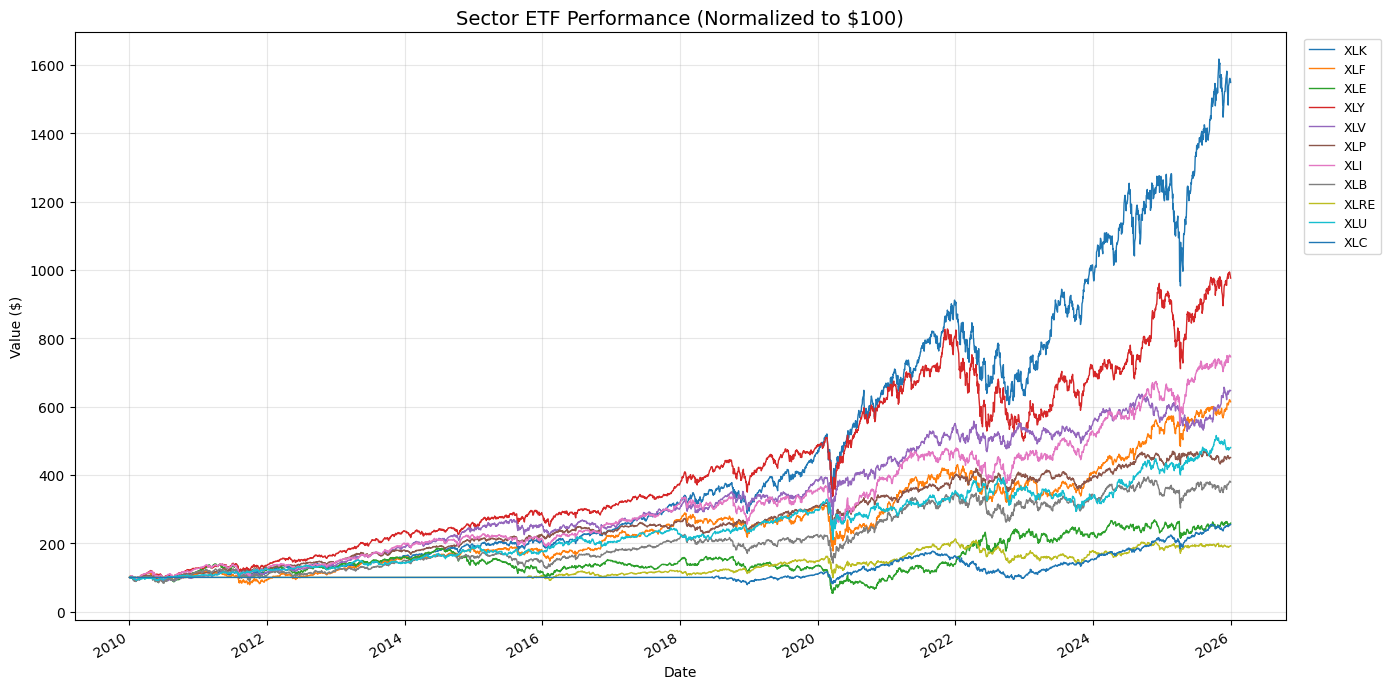

In [9]:
# Plot all ETF prices normalized to $100 at start (so we can compare growth)
prices = data["prices"]
normalized = prices / prices.iloc[0] * 100  # Start everyone at $100

fig, ax = plt.subplots(figsize=(14, 7))
normalized.plot(ax=ax, linewidth=1)
ax.set_title("Sector ETF Performance (Normalized to $100)", fontsize=14)
ax.set_ylabel("Value ($)")
ax.set_xlabel("Date")
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# QUESTION TO THINK ABOUT:
# If you had to pick just ONE sector to invest in, which would you choose?
# Now think: what if you could MIX them? That's portfolio optimization.

## Step 3: Understanding Returns

**Log returns** = ln(P_today / P_yesterday)

Why log returns instead of simple percentage changes?
- They're **additive over time** (sum of daily log returns = multi-day log return)
- They're closer to **normally distributed** (important for statistical modeling)
- They make cumulative return calculation a simple `cumsum()`

In [10]:
log_returns = data["log_returns"]

# Summary statistics for each ETF's daily returns
print("Daily Log Return Statistics:")
print("=" * 70)
stats = log_returns.describe().T[["mean", "std", "min", "max"]]
stats["annual_return"] = stats["mean"] * 252      # Annualize: multiply by trading days
stats["annual_vol"] = stats["std"] * np.sqrt(252)  # Annualize: multiply by sqrt(trading days)
stats["sharpe"] = stats["annual_return"] / stats["annual_vol"]
print(stats.round(4))

print("\n--- KEY INSIGHT ---")
print("Notice: daily returns are TINY (mean ~0.0004 = 0.04%)")
print("But annualized, that's ~10%/year. That's the power of compounding!")
print("Also notice: XLK has the highest Sharpe ratio — best return per unit of risk.")

Daily Log Return Statistics:
        mean     std     min     max  annual_return  annual_vol  sharpe
XLK   0.0007  0.0137 -0.1487  0.1260         0.1717      0.2175  0.7893
XLF   0.0005  0.0139 -0.1474  0.1236         0.1137      0.2201  0.5166
XLE   0.0002  0.0173 -0.2249  0.1487         0.0595      0.2742  0.2172
XLY   0.0006  0.0128 -0.1355  0.1034         0.1427      0.2039  0.6999
XLV   0.0005  0.0102 -0.1038  0.0742         0.1169      0.1619  0.7222
XLP   0.0004  0.0087 -0.0987  0.0817         0.0943      0.1373  0.6868
XLI   0.0005  0.0123 -0.1204  0.1191         0.1259      0.1945  0.6472
XLB   0.0003  0.0131 -0.1166  0.1112         0.0835      0.2085  0.4003
XLRE  0.0002  0.0104 -0.1744  0.0842         0.0409      0.1650  0.2481
XLU   0.0004  0.0110 -0.1206  0.1204         0.0983      0.1751  0.5615
XLC   0.0002  0.0098 -0.1197  0.0861         0.0585      0.1552  0.3772

--- KEY INSIGHT ---
Notice: daily returns are TINY (mean ~0.0004 = 0.04%)
But annualized, that's ~10%/year

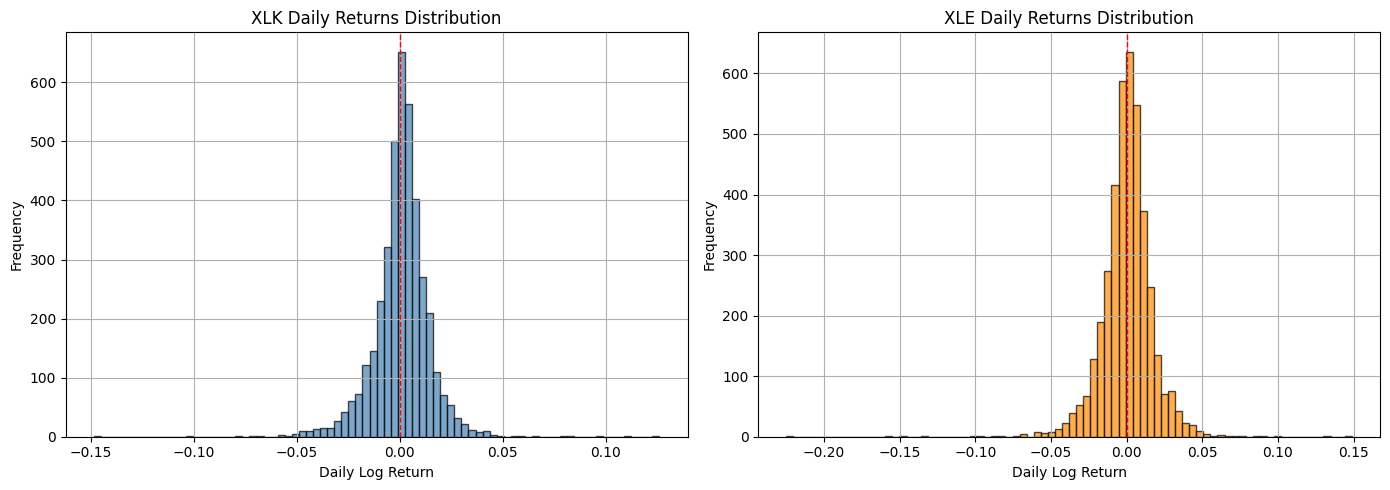

Notice: Both distributions look roughly bell-shaped (normal),
but they have 'fat tails' — extreme days happen more often than
a normal distribution predicts. This is why VaR and CVaR matter.


In [18]:
# Histogram of daily returns for two contrasting sectors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ticker, color in zip(axes, ["XLK", "XLE"], ["steelblue", "darkorange"]):
    log_returns[ticker].hist(bins=80, ax=ax, color=color, alpha=0.7, edgecolor="black")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{ticker} Daily Returns Distribution", fontsize=12)
    ax.set_xlabel("Daily Log Return")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Notice: Both distributions look roughly bell-shaped (normal),")
print("but they have 'fat tails' — extreme days happen more often than")
print("a normal distribution predicts. This is why VaR and CVaR matter.")

## Step 4: The Correlation Matrix — Why Diversification Works

The **correlation matrix** shows how sectors move together (-1 to +1).
- Correlation near **+1**: sectors move together (no diversification benefit)
- Correlation near **0**: sectors are independent (great for diversification)
- Correlation near **-1**: sectors move opposite (perfect hedge, very rare in stocks)

**The key insight of Markowitz**: If correlations < 1, combining assets reduces portfolio risk.

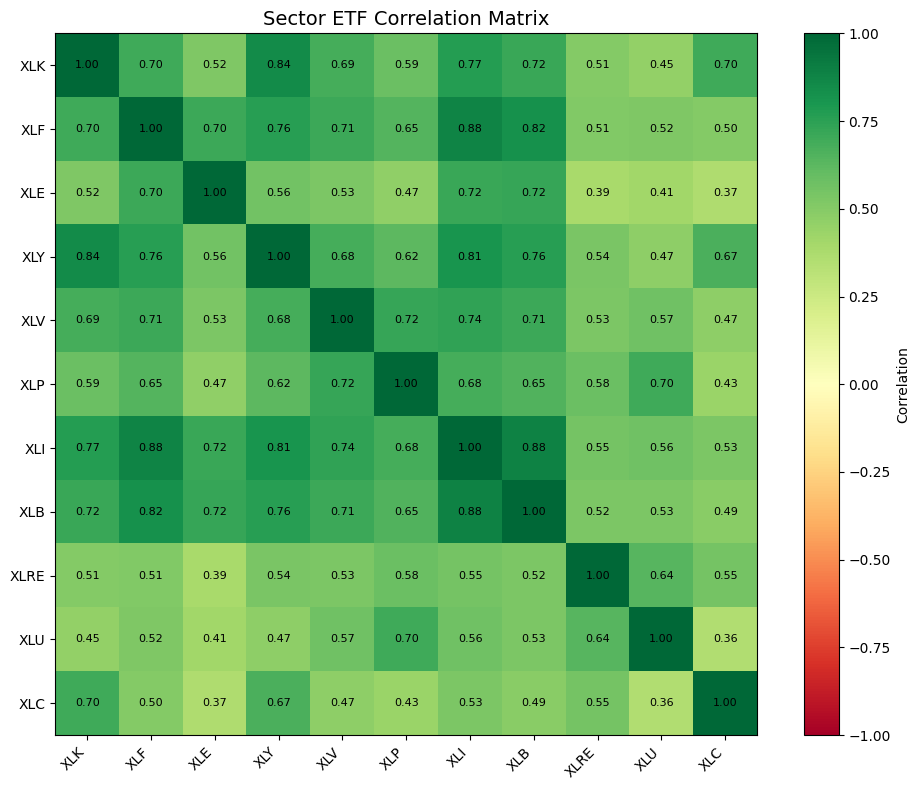

KEY OBSERVATIONS:
  Lowest correlation:  0.36 — some diversification benefit exists
  Average correlation: 0.61
  Most sectors are positively correlated (0.4-0.8) — they tend to move together
  But NOT perfectly — this gap between 1.0 and actual correlation is where diversification helps


In [19]:
# Correlation heatmap
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Sector ETF Correlation Matrix", fontsize=14)

# Add correlation values as text
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("KEY OBSERVATIONS:")
print(f"  Lowest correlation:  {corr.min().min():.2f} — some diversification benefit exists")
print(f"  Average correlation: {corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().mean():.2f}")
print("  Most sectors are positively correlated (0.4-0.8) — they tend to move together")
print("  But NOT perfectly — this gap between 1.0 and actual correlation is where diversification helps")

## Step 5: Markowitz Optimization

Now the core of the project. Given historical returns and covariances, find the **optimal portfolio weights**.

Two strategies:
- **Minimum Variance**: ignore returns, just minimize risk (useful when return estimates are noisy)
- **Maximum Sharpe**: maximize return-per-unit-of-risk (the "tangent portfolio")

In [11]:
# Use the TRAINING set only (no peeking at the future!)
train_returns = data["train"]

# Step 1: Estimate parameters (annualized mean returns + covariance matrix)
mean_ret, cov_mat = estimate_parameters(train_returns)

# Step 2: Find optimal weights
mv_weights = minimum_variance_weights(cov_mat)
ms_weights = max_sharpe_weights(mean_ret, cov_mat)

# Step 3: Compute portfolio metrics
mv_ret, mv_vol = portfolio_performance(mv_weights, mean_ret, cov_mat)
ms_ret, ms_vol = portfolio_performance(ms_weights, mean_ret, cov_mat)

# Also compute equal-weight benchmark for comparison
eq_weights = np.ones(len(TICKERS)) / len(TICKERS)
eq_ret, eq_vol = portfolio_performance(eq_weights, mean_ret, cov_mat)

# Display results
print("Portfolio Comparison (based on training data)")
print("=" * 60)
print(f"{'Strategy':<20} {'Return':>10} {'Volatility':>12} {'Sharpe':>10}")
print("-" * 60)
for name, ret, vol in [
    ("Equal Weight", eq_ret, eq_vol),
    ("Min Variance", mv_ret, mv_vol),
    ("Max Sharpe", ms_ret, ms_vol),
]:
    print(f"{name:<20} {ret:>10.2%} {vol:>12.2%} {ret/vol:>10.2f}")

print("\n--- INSIGHT ---")
print("The Max Sharpe portfolio has a HIGHER Sharpe ratio than equal weight.")
print("That's the value of optimization — better return for the same risk.")

Portfolio Comparison (based on training data)
Strategy                 Return   Volatility     Sharpe
------------------------------------------------------------
Equal Weight             10.10%       15.79%       0.64
Min Variance              6.19%       11.22%       0.55
Max Sharpe               15.01%       16.40%       0.91

--- INSIGHT ---
The Max Sharpe portfolio has a HIGHER Sharpe ratio than equal weight.
That's the value of optimization — better return for the same risk.


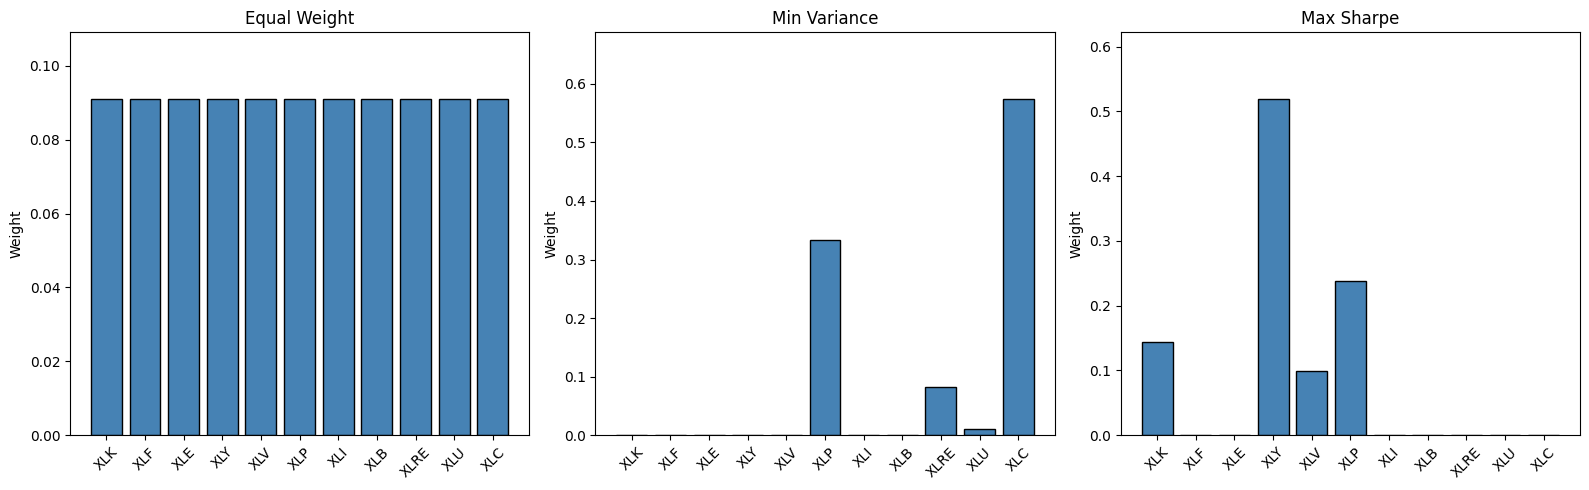

Notice: Max Sharpe concentrates heavily in a few sectors.
This is the 'estimation error' problem — the optimizer is overconfident
about small differences in expected returns.


In [12]:
# Visualize the weights — where does each strategy put its money?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, weights, title in zip(axes,
    [eq_weights, mv_weights, ms_weights],
    ["Equal Weight", "Min Variance", "Max Sharpe"]):
    bars = ax.bar(TICKERS, weights, color="steelblue", edgecolor="black")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Weight")
    ax.set_ylim(0, max(weights.max(), eq_weights.max()) * 1.2)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Notice: Max Sharpe concentrates heavily in a few sectors.")
print("This is the 'estimation error' problem — the optimizer is overconfident")
print("about small differences in expected returns.")

## Step 6: The Efficient Frontier

The curve of all optimal portfolios. Every point on this curve is the **best possible
portfolio** for a given level of risk. Anything below the curve is suboptimal.

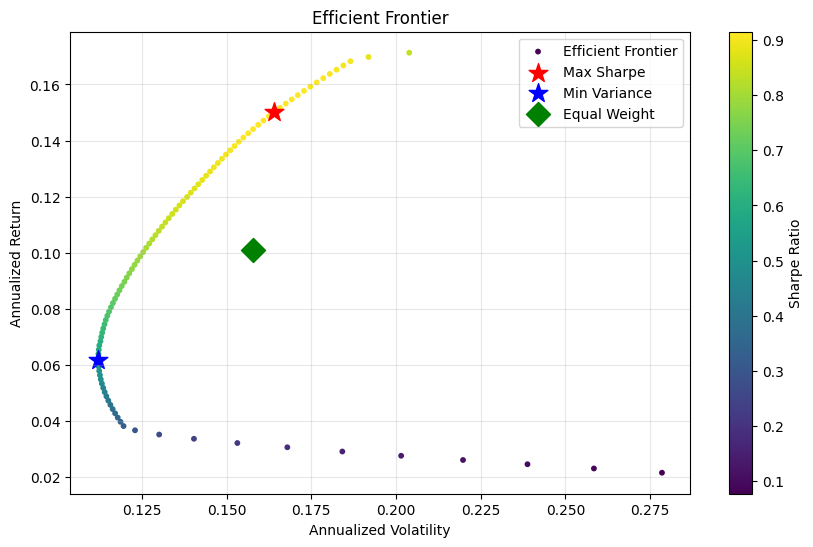

The CURVE shows the diversification benefit — you can get higher returns
without proportionally more risk by choosing the right mix of assets.


In [13]:
# Compute the efficient frontier (100 points along the curve)
frontier = efficient_frontier(mean_ret, cov_mat, n_points=100)

# Plot it with our optimal portfolios marked
fig = plot_efficient_frontier(
    frontier,
    max_sharpe_point=(ms_vol, ms_ret),
    min_var_point=(mv_vol, mv_ret),
)

# Also add equal-weight for reference
plt.scatter(eq_vol, eq_ret, color="green", marker="D", s=150, label="Equal Weight", zorder=5)
plt.legend()
plt.show()

print("The CURVE shows the diversification benefit — you can get higher returns")
print("without proportionally more risk by choosing the right mix of assets.")

## Step 7: Backtesting — How Would This Have Actually Performed?

Static optimization uses ONE set of weights forever. But markets change!
**Rolling backtest** re-optimizes monthly using the most recent year of data,
simulating what a real investor would have done.

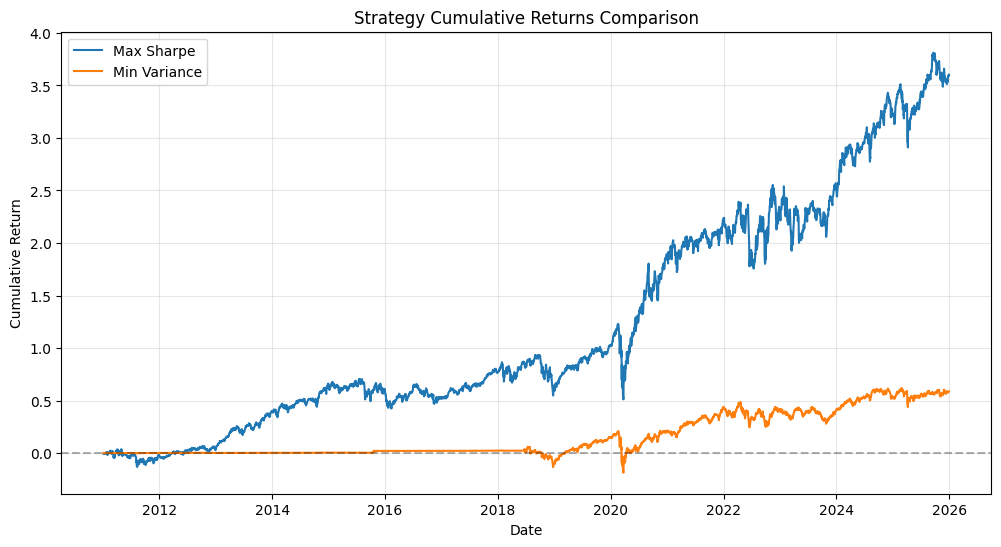


Risk Metrics Comparison
Metric                         Max Sharpe    Min Variance
-----------------------------------------------------------------
annualized_return                  0.1021          0.0309
annualized_volatility              0.1794          0.1138
sharpe_ratio                       0.5688          0.2711
sortino_ratio                      0.6836          0.2781
max_drawdown                      -0.3457         -0.3467
var_95                            -0.0174         -0.0093
cvar_95                           -0.0278         -0.0176


In [23]:
# Run rolling backtests for both strategies
bt_sharpe = rolling_backtest(log_returns, window=252, strategy="max_sharpe", rebalance_freq=21)
bt_minvar = rolling_backtest(log_returns, window=252, strategy="min_variance", rebalance_freq=21)

# Plot cumulative returns
fig = plot_cumulative_returns({"Max Sharpe": bt_sharpe, "Min Variance": bt_minvar})
plt.show()

# Compute risk metrics for both
print("\nRisk Metrics Comparison")
print("=" * 65)
print(f"{'Metric':<25} {'Max Sharpe':>15} {'Min Variance':>15}")
print("-" * 65)

metrics_ms = compute_all_metrics(bt_sharpe["portfolio_return"])
metrics_mv = compute_all_metrics(bt_minvar["portfolio_return"])

for key in metrics_ms:
    print(f"{key:<25} {metrics_ms[key]:>15.4f} {metrics_mv[key]:>15.4f}")

## Step 8: Regime Analysis — When Does MVO Break Down?

This is the key research question: do these strategies behave differently
in **calm markets** vs **crisis periods**? If MVO fails during crises,
that's where LSTM might add value.

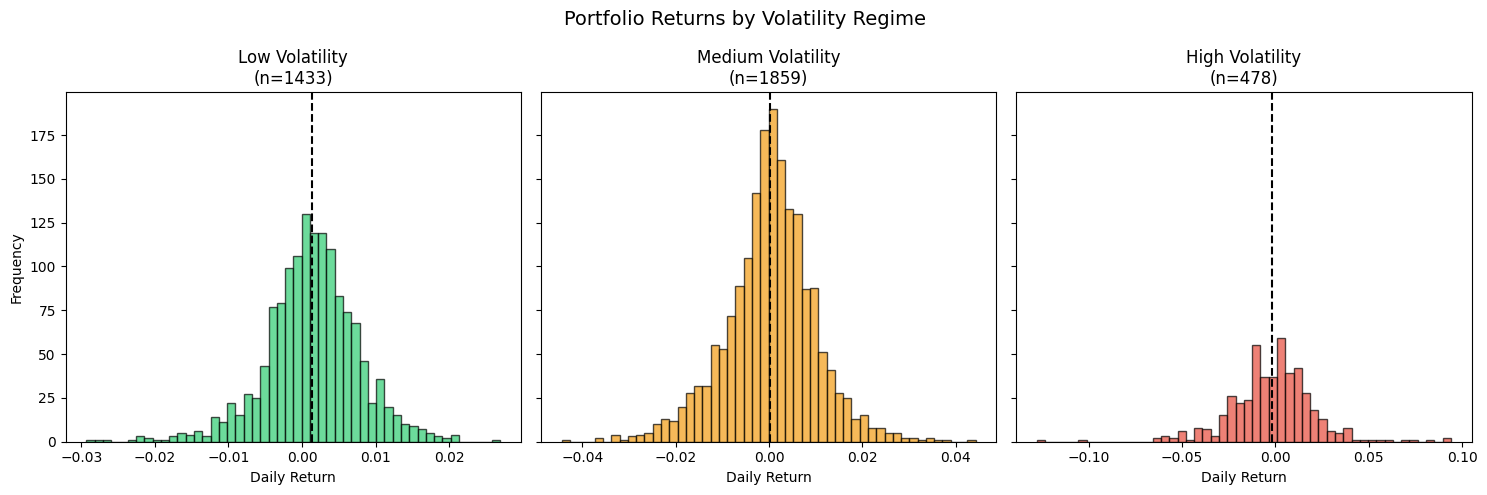


Max Sharpe Performance by Volatility Regime

LOW volatility (1433 days):
  Annualized Return:  0.3384
  Annualized Vol:     0.1010
  Sharpe Ratio:       3.3516
  Max Drawdown:       -0.1120

MEDIUM volatility (1859 days):
  Annualized Return:  0.0670
  Annualized Vol:     0.1544
  Sharpe Ratio:       0.4341
  Max Drawdown:       -0.4208

HIGH volatility (478 days):
  Annualized Return:  -0.4704
  Annualized Vol:     0.3589
  Sharpe Ratio:       -1.3106
  Max Drawdown:       -0.6601


In [24]:
# Align regime labels with backtest dates
regime = data["regime_vix"].reindex(bt_sharpe.index).ffill()

# Plot returns by regime
fig = plot_regime_returns(bt_sharpe["portfolio_return"], regime)
plt.show()

# Metrics broken down by regime
print("\nMax Sharpe Performance by Volatility Regime")
print("=" * 65)
for regime_name in ["low", "medium", "high"]:
    mask = regime == regime_name
    if mask.sum() > 0:
        regime_returns = bt_sharpe.loc[mask, "portfolio_return"]
        metrics = compute_all_metrics(regime_returns)
        print(f"\n{regime_name.upper()} volatility ({mask.sum()} days):")
        print(f"  Annualized Return:  {metrics['annualized_return']:.4f}")
        print(f"  Annualized Vol:     {metrics['annualized_volatility']:.4f}")
        print(f"  Sharpe Ratio:       {metrics['sharpe_ratio']:.4f}")
        print(f"  Max Drawdown:       {metrics['max_drawdown']:.4f}")

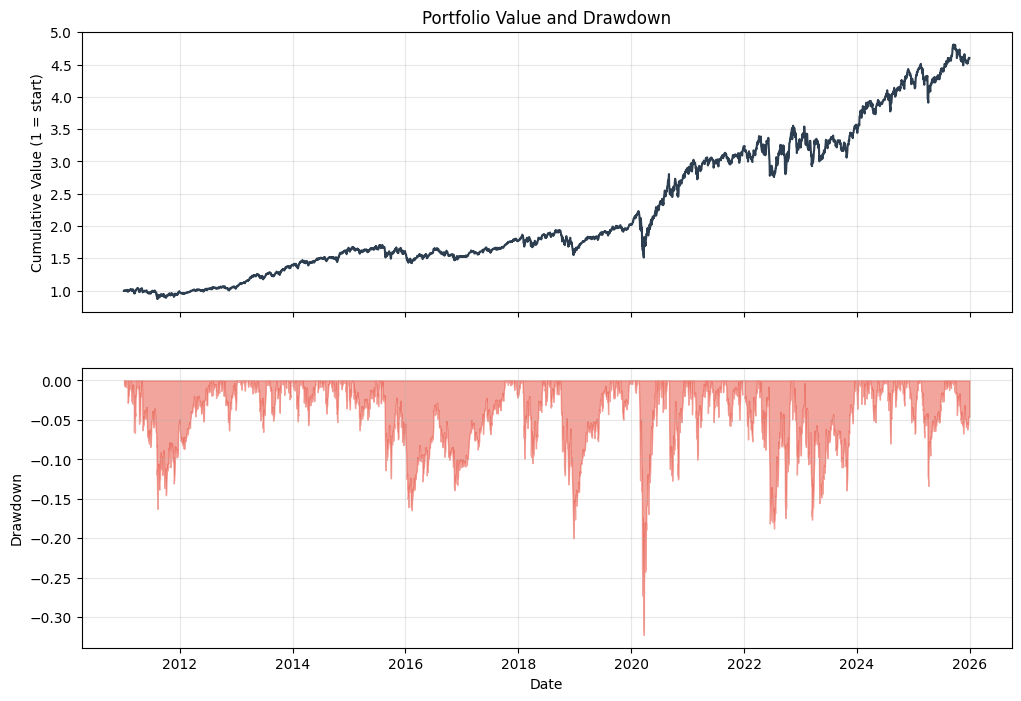

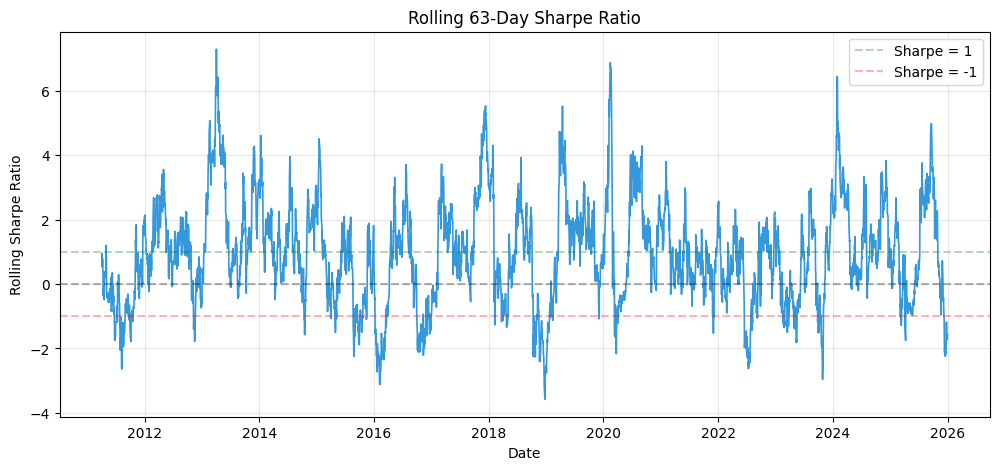

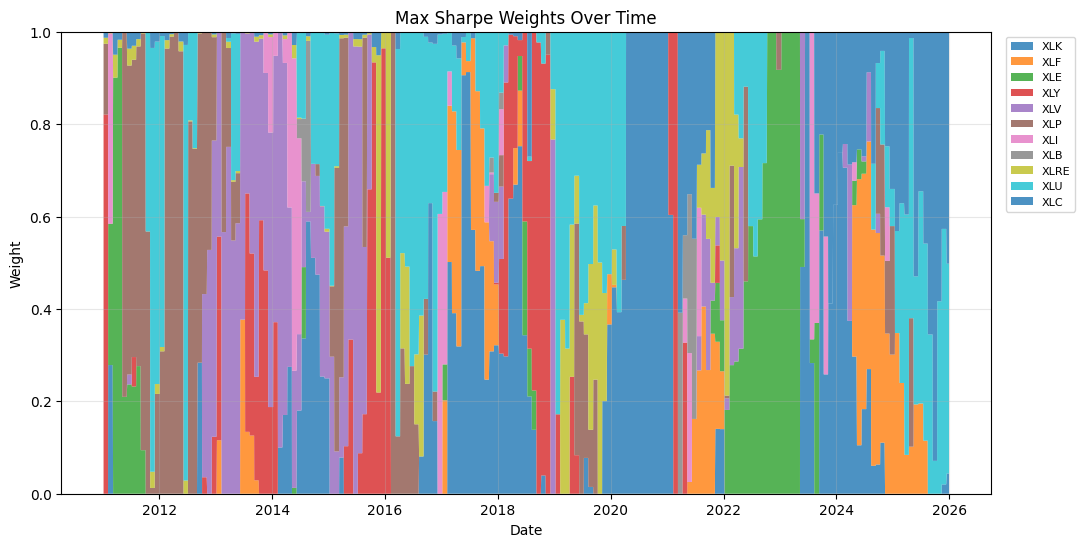

In [25]:
# Drawdown chart — see where the pain is
fig = plot_drawdown(bt_sharpe)
plt.show()

# Rolling Sharpe — see how performance varies over time
fig = plot_rolling_sharpe(bt_sharpe)
plt.show()

# Weight allocation — see how the optimizer shifts money around
fig = plot_weight_allocation(bt_sharpe, asset_columns=TICKERS, title="Max Sharpe Weights Over Time")
plt.show()

## Summary & Next Steps

**What we've learned:**
1. Sector ETFs provide diversified exposure to the US equity market
2. Log returns are the standard representation for financial time series
3. Correlations < 1 create a **diversification benefit** that Markowitz exploits
4. MVO finds mathematically optimal portfolios, but is sensitive to estimation error
5. Rolling backtests simulate realistic historical performance
6. Performance varies significantly across volatility regimes

**Research question for the LSTM phase:**
> Can LSTM-based return forecasts produce **better** expected return estimates
> than the simple historical mean, especially during high-volatility regimes?

If LSTM can predict the *direction* of returns more accurately during crises,
the optimizer will produce better weights, and the portfolio will suffer smaller drawdowns.

**Next notebook:** `02_lstm_forecasting.ipynb` (TODO)